In [ ]:
import sys
import os
import glob
import re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.data import Batch
from torch.utils.data import ConcatDataset, random_split, DataLoader
from typing import List, Dict, Any, Optional, Tuple
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pathlib

# Add project root to path
PROJECT_ROOT = "/mnt/c/Users/obbee/research/notebooks/ML"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
    os.environ["PYTHONPATH"] = PROJECT_ROOT + os.pathsep + os.environ.get("PYTHONPATH", "")

from graph_data.event_mixer import MixedEventDataset
from graph_data.models import EventBuilder
from graph_data.utils import build_event_graph
from graph_data.plotting import plot_endpoint_error_distributions, plot_pull_distributions, plot_event_display

In [2]:
def collate_batch(containers):
    """
    Custom collate function for batching variable-sized EventContainers.
    Builds graphs on CPU, then moves to GPU in the training loop.
    """
    # Lists to store CPU tensors
    batch_x = []
    batch_edge_index = []
    batch_edge_attr = []
    batch_group_indices = []
    batch_targets = []
    batch_indices_per_group = [] 
    
    node_offset = 0
    group_offset = 0
    
    valid_batch_idx = 0 # Counter for valid events (skipping None)
    
    for container in containers:
        # 1. Build on CPU first to avoid PCIe latency inside loop
        try:
            # Assuming build_event_graph is defined in a previous cell or imported
            graph_data = build_event_graph(container, device='cpu', radius_z=50.0)
        except Exception as e:
            # print(f"Skipping malformed event: {e}") # Optional debug
            continue
            
        if graph_data is None:
            continue
            
        x, edge_idx, edge_attr, groups, num_groups, targets = graph_data
        
        # 2. Add to lists
        batch_x.append(x)
        batch_edge_attr.append(edge_attr)
        batch_targets.append(targets)
        
        # 3. Apply Offsets
        batch_edge_index.append(edge_idx + node_offset)
        batch_group_indices.append(groups + group_offset)
        
        # 4. Create Batch Vector (using valid_batch_idx to keep block diagonal clean)
        batch_indices_per_group.append(torch.full((num_groups,), valid_batch_idx, dtype=torch.long))

        # Update offsets
        node_offset += x.size(0)
        group_offset += num_groups
        valid_batch_idx += 1

    # Safety check: Did we filter out the entire batch?
    if len(batch_x) == 0:
        return None

    # 5. Concatenate on CPU
    big_x = torch.cat(batch_x, dim=0)
    big_edge_index = torch.cat(batch_edge_index, dim=1)
    big_edge_attr = torch.cat(batch_edge_attr, dim=0)
    big_group_indices = torch.cat(batch_group_indices, dim=0)
    big_batch_indices = torch.cat(batch_indices_per_group, dim=0)
    
    # Block Diagonal Targets
    big_targets = torch.block_diag(*batch_targets)
    
    # 6. Return CPU tensors (We move to DEVICE in the training loop)
    return (
        big_x,
        big_edge_index,
        big_edge_attr,
        big_group_indices,
        big_batch_indices,
        big_targets
    )

In [3]:
def evaluate_pairwise_predictions(all_targets, all_preds, epoch, threshold=0.5, show_plot=True):
    """
    Args:
        all_targets: List of 1D tensors (0 or 1)
        all_preds: List of 1D tensors (probabilities 0.0 to 1.0)
    """
    # Concatenate and move to CPU/Numpy
    y_true = torch.cat(all_targets).cpu().numpy()
    y_pred_probs = torch.cat(all_preds).cpu().numpy()
    
    # Thresholding
    y_pred = (y_pred_probs >= threshold).astype(int)

    # Confusion matrix elements
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    
    cm = np.array([[tn, fp], [fn, tp]])

    # Metrics with divide-by-zero safety
    total = max(1, len(y_true))
    acc = (tp + tn) / total
    prec = tp / max(1, (tp + fp))
    rec = tp / max(1, (tp + fn))
    f1 = 2 * prec * rec / max(1e-8, (prec + rec))

    print(f"\n--- Confusion Matrix (Epoch {epoch}) ---")
    print(f"Total Pairs Evaluated: {total}")
    print(f"TN: {tn} | FP: {fp}")
    print(f"FN: {fn} | TP: {tp}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    if show_plot:
        plt.figure(figsize=(5, 4))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(f'Confusion Matrix — Epoch {epoch}')
        plt.colorbar()
        plt.xticks([0,1], ['Diff Event (0)', 'Same Event (1)'])
        plt.yticks([0,1], ['Diff Event (0)', 'Same Event (1)'])
        
        # Text annotations
        thresh = cm.max() / 2.
        for i in range(2):
            for j in range(2):
                plt.text(j, i, format(cm[i, j], 'd'),
                         ha="center", va="center",
                         color="white" if cm[i, j] > thresh else "black")
        
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.tight_layout()
        plt.show()

In [4]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=20):
    """
    Runs the training and validation loop for the EventBuilder model.
    """
    # Metrics tracking
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_pos_acc': []
    }

    print(f"Starting training for {epochs} epochs on {device}...")

    for epoch in range(1, epochs + 1):
        torch.cuda.empty_cache()
        # --- TRAIN LOOP ---
        model.train()
        train_loss = 0
        train_steps = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]", leave=False)
        
        for batch in pbar:
            if batch is None: continue
                
            x_cpu, edge_index_cpu, edge_attr_cpu, groups_cpu, batch_indices_cpu, targets_cpu = batch
            
            x = x_cpu.to(device)
            edge_index = edge_index_cpu.to(device)
            edge_attr = edge_attr_cpu.to(device)
            groups = groups_cpu.to(device)
            batch_indices = batch_indices_cpu.to(device)
            targets = targets_cpu.to(device)
            
            optimizer.zero_grad()
            
            # Forward Pass
            affinity_pred = model(x, edge_index, edge_attr, groups, batch_indices)
            
            # Loss Calculation (Masked)
            batch_ids = batch_indices.unsqueeze(1)
            event_mask_bool = (batch_ids == batch_ids.T)       # For Indexing
            event_mask_float = event_mask_bool.float()         # For Math
            
            raw_loss = criterion(affinity_pred, targets)
            loss = (raw_loss * event_mask_float).sum() / (event_mask_float.sum() + 1e-6)
            
            loss.backward()
            optimizer.step()

            del x_cpu, edge_index_cpu, edge_attr_cpu, groups_cpu, batch_indices_cpu, targets_cpu
            
            train_loss += loss.item()
            train_steps += 1
            
            # Live Monitor: Train Accuracy (Positive Class Only)
            with torch.no_grad():
                pos_mask = (targets == 1) & (event_mask_bool == 1)
                if pos_mask.sum() > 0:
                    acc = (affinity_pred[pos_mask] > 0.5).float().mean().item()
                else:
                    acc = 0.0
            pbar.set_postfix(loss=loss.item(), acc=f"{acc:.2f}")

        avg_train_loss = train_loss / max(1, train_steps)
        history['train_loss'].append(avg_train_loss)

        # --- VALIDATION LOOP ---
        model.train()
        val_loss = 0
        val_steps = 0
        val_pos_acc = 0

        all_val_preds = []
        all_val_targets = []
        
        with torch.no_grad():
            for batch in val_loader:
                if batch is None: continue
                
                # Unpack & Move
                x_cpu, edge_index_cpu, edge_attr_cpu, groups_cpu, batch_indices_cpu, targets_cpu = batch
                
                x = x_cpu.to(device)
                edge_index = edge_index_cpu.to(device)
                edge_attr = edge_attr_cpu.to(device)
                groups = groups_cpu.to(device)
                batch_indices = batch_indices_cpu.to(device)
                targets = targets_cpu.to(device)
                
                # Forward
                affinity_pred = model(x, edge_index, edge_attr, groups, batch_indices)
                
                # Loss
                batch_ids = batch_indices.unsqueeze(1)
                event_mask_bool = (batch_ids == batch_ids.T) # Bool
                event_mask_float = event_mask_bool.float()   # Float
                
                raw_loss = criterion(affinity_pred, targets)
                loss = (raw_loss * event_mask_float).sum() / (event_mask_float.sum() + 1e-6)
                
                val_loss += loss.item()
                val_steps += 1
                
                # --- COLLECT PREDICTIONS ---
                
                # 1. Create Diagonal Mask (Identity Matrix)
                # FIX: Use batch_indices size (Total Groups), NOT groups size (Total Hits)
                num_groups = batch_indices.size(0) 
                diag_mask = torch.eye(num_groups, device=device).bool()
                
                # 2. Combine: Must be (Same Event) AND (Not Diagonal)
                valid_pair_mask = event_mask_bool & (~diag_mask)
                
                # 3. Indexing
                valid_preds = affinity_pred[valid_pair_mask] 
                valid_targets = targets[valid_pair_mask]
                
                # 4. Move to CPU and append to list
                all_val_preds.append(valid_preds.cpu())
                all_val_targets.append(valid_targets.cpu())

                del x_cpu, edge_index_cpu, edge_attr_cpu, groups_cpu, batch_indices_cpu, targets_cpu
                
        avg_val_loss = val_loss / max(1, val_steps)
        history['val_loss'].append(avg_val_loss)
        
        print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        evaluate_pairwise_predictions(
            all_targets=all_val_targets, 
            all_preds=all_val_preds, 
            epoch=epoch, 
            show_plot=True
        )

    print("Training Complete.")
    return history

In [5]:
chunk_files = glob.glob(PROJECT_ROOT + "/processed/*.pt")
chunk_files.sort()
datasets = [MixedEventDataset(path) for path in chunk_files]

Loading dataset from /mnt/c/Users/obbee/research/notebooks/ML/processed/mixed_chunk_0.pt...
Loading dataset from /mnt/c/Users/obbee/research/notebooks/ML/processed/mixed_chunk_10000.pt...
Loading dataset from /mnt/c/Users/obbee/research/notebooks/ML/processed/mixed_chunk_20000.pt...
Loading dataset from /mnt/c/Users/obbee/research/notebooks/ML/processed/mixed_chunk_30000.pt...
Loading dataset from /mnt/c/Users/obbee/research/notebooks/ML/processed/mixed_chunk_40000.pt...
Loading dataset from /mnt/c/Users/obbee/research/notebooks/ML/processed/mixed_chunk_50000.pt...
Loading dataset from /mnt/c/Users/obbee/research/notebooks/ML/processed/mixed_chunk_60000.pt...
Loading dataset from /mnt/c/Users/obbee/research/notebooks/ML/processed/mixed_chunk_70000.pt...
Loading dataset from /mnt/c/Users/obbee/research/notebooks/ML/processed/mixed_chunk_80000.pt...
Loading dataset from /mnt/c/Users/obbee/research/notebooks/ML/processed/mixed_chunk_90000.pt...


In [6]:
VAL_FRAC = 0.1
BATCH_SIZE = 24
NUM_WORKERS = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [7]:
# 1. Load Full Dataset
full_dataset = ConcatDataset(datasets)
total_len = len(full_dataset)
    
# 2. Split 80/20
train_len = int((1-VAL_FRAC) * total_len)
val_len = total_len - train_len
train_subset, val_subset = random_split(full_dataset, [train_len, val_len])

print(f"Dataset Loaded. Total: {total_len}")
print(f"  Training:   {train_len} events")
print(f"  Validation: {val_len} events")

# 3. Create Loaders
# Note: We use the same collate_fn for both
train_loader = DataLoader(
    train_subset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_batch,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_subset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=NUM_WORKERS
)

Dataset Loaded. Total: 100000
  Training:   90000 events
  Validation: 10000 events


In [8]:
model = EventBuilder(
    in_channels=25, hidden=128, heads=4, layers=3, dropout=0.1
).to(DEVICE)

In [9]:
optimizer = optim.AdamW(model.parameters(), lr=3e-5)
criterion = nn.BCELoss(reduction='none')

Starting training for 10 epochs on cuda...


Epoch 1 | Train Loss: 0.0093 | Val Loss: 0.0097

--- Confusion Matrix (Epoch 1) ---
Total Pairs Evaluated: 86318
TN: 27432 | FP: 286
FN: 68 | TP: 58532
Accuracy:  0.9959
Precision: 0.9951
Recall:    0.9988
F1 Score:  0.9970


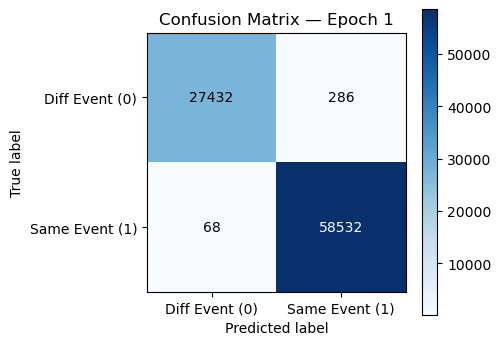

Epoch 2 [Train]:   0%|          | 0/3750 [00:00<?, ?it/s]/home/omar/miniconda3/envs/research/lib/python3.10/site-packages/torch_geometric/warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)


KeyboardInterrupt: 

In [14]:
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    epochs=10
)

In [19]:
import importlib
import graph_data.plotting
importlib.reload(graph_data.utils)
importlib.reload(graph_data.plotting)

<module 'graph_data.plotting' from '/mnt/c/Users/obbee/research/notebooks/ML/graph_data/plotting.py'>

In [24]:
import scipy.sparse as sp

def matrix_to_groups_local(matrix_cpu, threshold=0.5):
    """Helper to convert NxN matrix to list of connected indices."""
    adj = (matrix_cpu > threshold).float().numpy()
    n_components, labels = sp.csgraph.connected_components(
        csgraph=sp.csr_matrix(adj), 
        directed=False, 
        return_labels=True
    )
    groups = [[] for _ in range(n_components)]
    for idx, label in enumerate(labels):
        groups[label].append(idx)
    return groups

def find_builder_failures(model, dataset, device, threshold=0.5, max_events=500):
    """
    Scans the dataset using the trained EventBuilder and finds events where
    the predicted connectivity graph does not match the truth.
    Returns extended metadata including the specific group sets.
    """
    print(f"Scanning first {max_events} events for topology failures...")
    model.train()
    failures = []
    
    loader = DataLoader(dataset, batch_size=1, collate_fn=collate_batch, shuffle=False)
    
    with torch.no_grad():
        for i, batch in enumerate(tqdm(loader, total=min(len(dataset), max_events))):
            if i >= max_events: break
            if batch is None: continue
            
            x_cpu, edge_idx_cpu, edge_attr_cpu, groups_cpu, batch_idx_cpu, targets_cpu = batch
            
            # Move to device
            x = x_cpu.to(device)
            edge_index = edge_idx_cpu.to(device)
            edge_attr = edge_attr_cpu.to(device)
            groups = groups_cpu.to(device)
            batch_indices = batch_idx_cpu.to(device)
            targets = targets_cpu.to(device)
            
            preds = model(x, edge_index, edge_attr, groups, batch_indices)
            binary_preds = (preds > threshold).float()
            
            # Create Masks
            b_ids = batch_indices.unsqueeze(1)
            event_mask = (b_ids == b_ids.T)
            num_groups = batch_indices.size(0)
            diag_mask = torch.eye(num_groups, device=device).bool()
            valid_mask = event_mask & (~diag_mask)
            
            # Calculate Errors
            fp = ((binary_preds == 1) & (targets == 0) & valid_mask).sum().item()
            fn = ((binary_preds == 0) & (targets == 1) & valid_mask).sum().item()
            
            if fp > 0 or fn > 0:
                # --- NEW: Convert Matrices to Group Sets ---
                # Move to CPU once for processing
                targets_cpu_mat = targets.cpu()
                preds_cpu_mat = preds.cpu()
                
                truth_sets = matrix_to_groups_local(targets_cpu_mat, threshold=0.5) # Truth usually 0 or 1
                reco_sets = matrix_to_groups_local(preds_cpu_mat, threshold=threshold)
                
                failures.append({
                    'index': i,
                    'fp': fp,
                    'fn': fn,
                    'total': fp + fn,
                    'truth_groups': truth_sets,
                    'reco_groups': reco_sets
                })
                # Optional: Uncomment if you want to see the matrices
                # print(f"Event {i}: Truth={truth_sets} -> Reco={reco_sets}")

    # failures.sort(key=lambda x: x['total'], reverse=True)
    print(f"Found {len(failures)} events with topology errors.")
    return failures

In [25]:
def visualize_pileup_comparison(dataset, failure_meta):
    """
    Plots the Ground Truth vs Model Prediction using the 'pileup' color mode.
    Uses the pre-calculated groups from find_builder_failures.
    """
    idx = failure_meta['index']
    fp = failure_meta['fp']
    fn = failure_meta['fn']
    
    print(f"--- Event {idx} Analysis (FP={fp}, FN={fn}) ---")
    
    # 1. Get the Raw Event Data
    container = dataset[idx]
    
    # 2. Extract the pre-calculated sets
    truth_sets = failure_meta['truth_groups']
    reco_sets = failure_meta['reco_groups']
    
    # 3. Plot Ground Truth
    print(f"Ground Truth: {len(truth_sets)} Distinct Events")
    plot_event_display(
        container.records,
        color_mode='pileup',         # <--- New Mode
        pileup_sets=truth_sets,      # <--- Pass Truth Sets
        title=f"Event {idx} GROUND TRUTH",
        fixed_axes=True
    )
    
    # 4. Plot Prediction
    print(f"Prediction: {len(reco_sets)} Reconstructed Events")
    plot_event_display(
        container.records,
        color_mode='pileup',         # <--- New Mode
        pileup_sets=reco_sets,       # <--- Pass Reco Sets
        title=f"Event {idx} PREDICTION (FP={fp}, FN={fn})",
        fixed_axes=True
    )

Scanning first 1000 events for topology failures...


100%|██████████| 1000/1000 [00:10<00:00, 96.73it/s]


Found 10 events with topology errors.
--- Event 57 Analysis (FP=4, FN=0) ---
Ground Truth: 3 Distinct Events


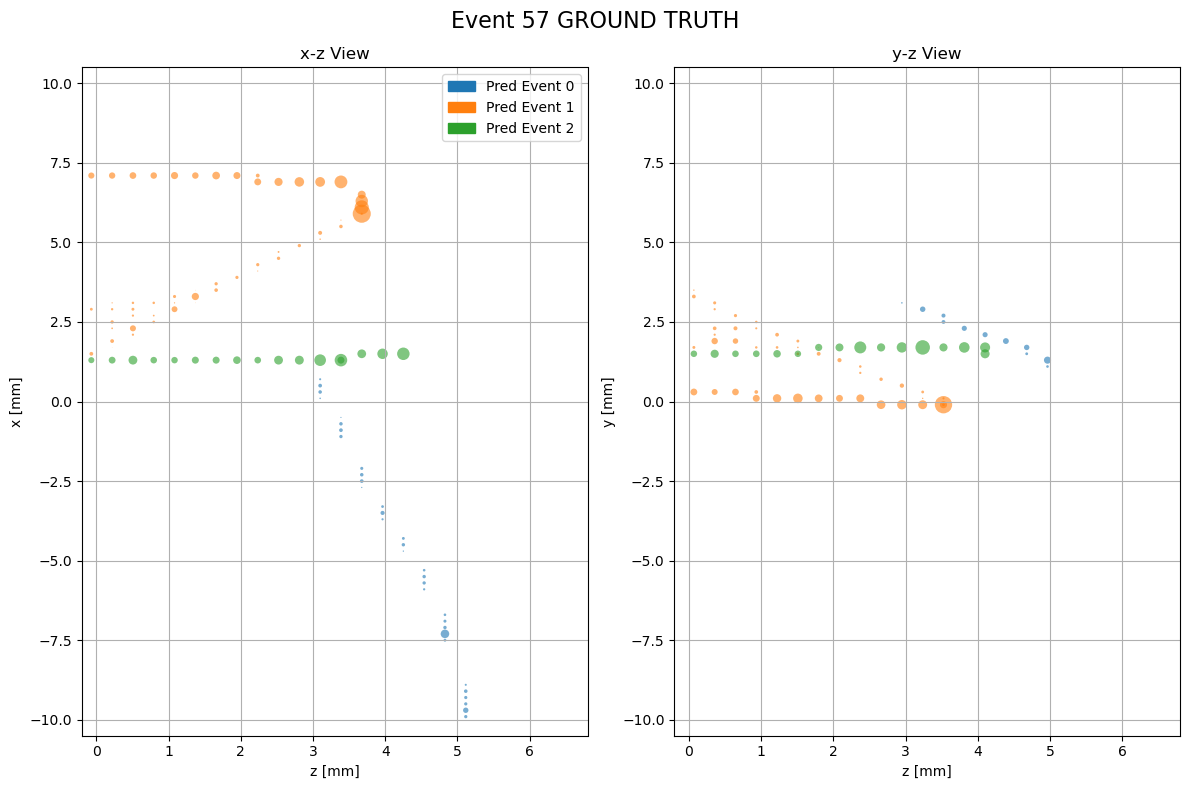

Prediction: 2 Reconstructed Events


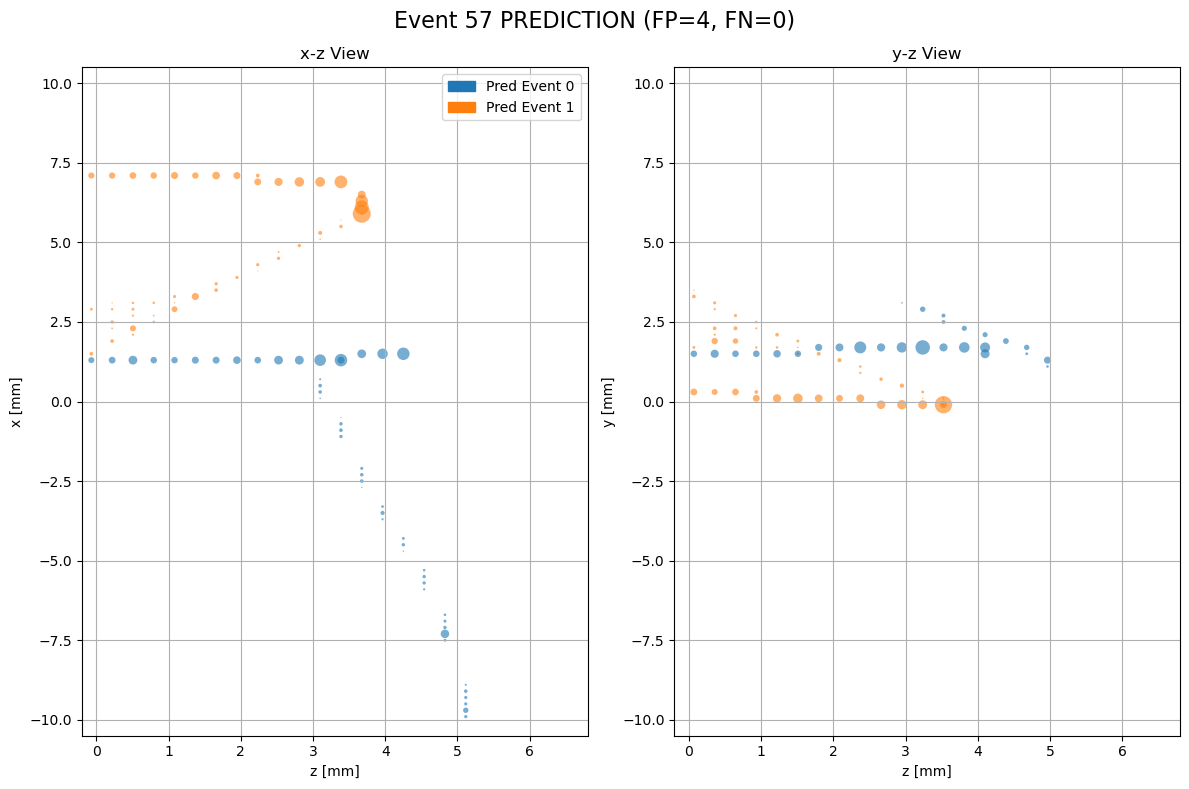

--- Event 70 Analysis (FP=2, FN=4) ---
Ground Truth: 2 Distinct Events


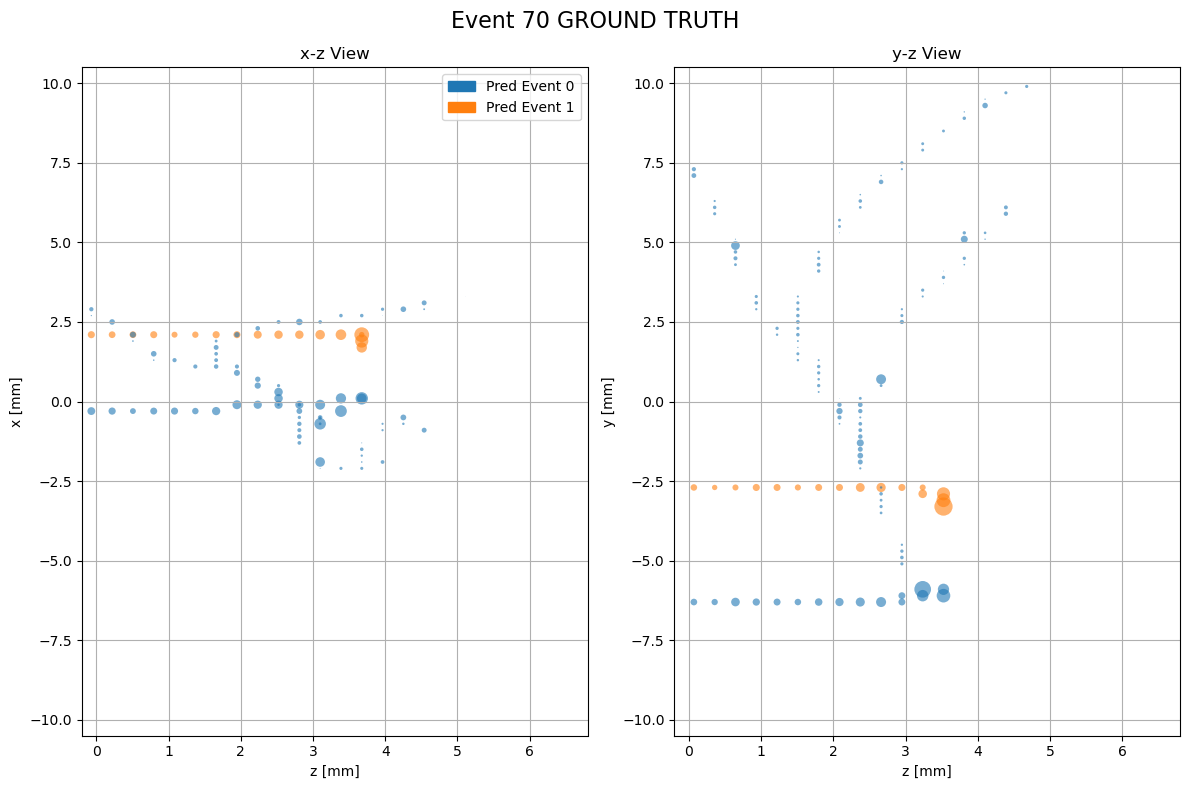

Prediction: 2 Reconstructed Events


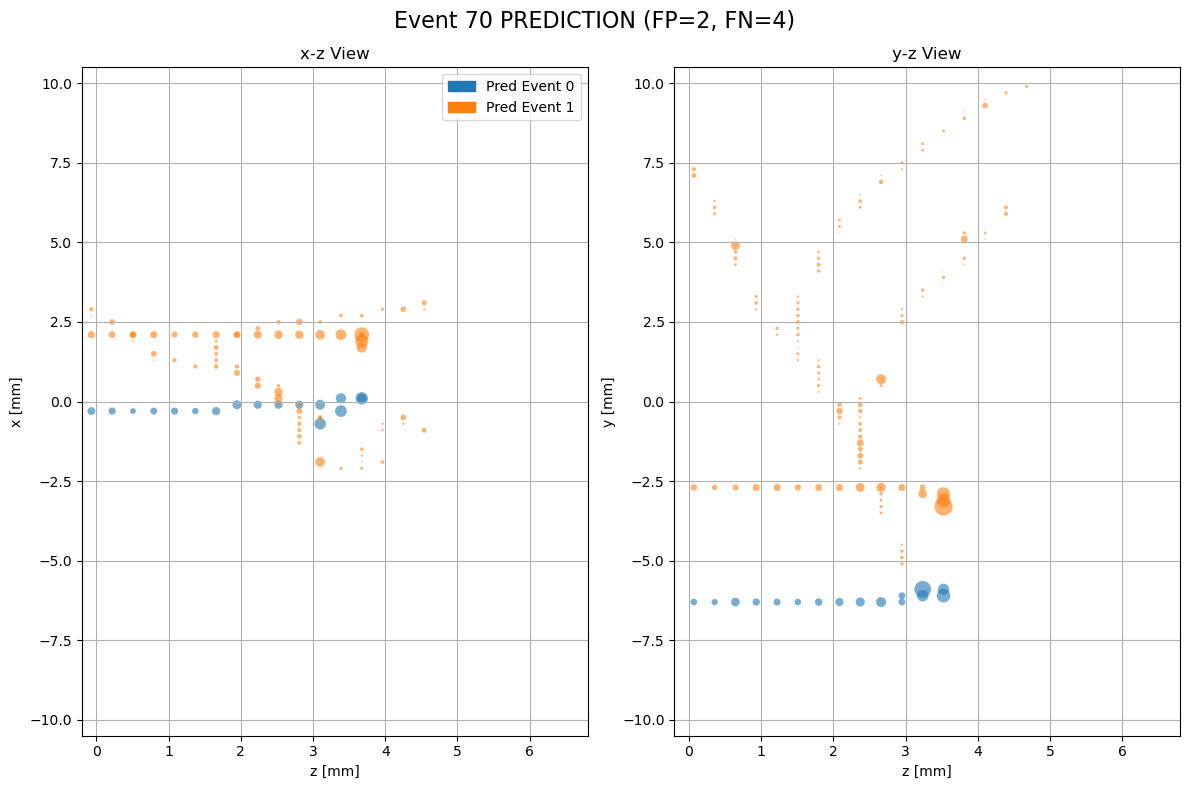

--- Event 111 Analysis (FP=2, FN=0) ---
Ground Truth: 3 Distinct Events


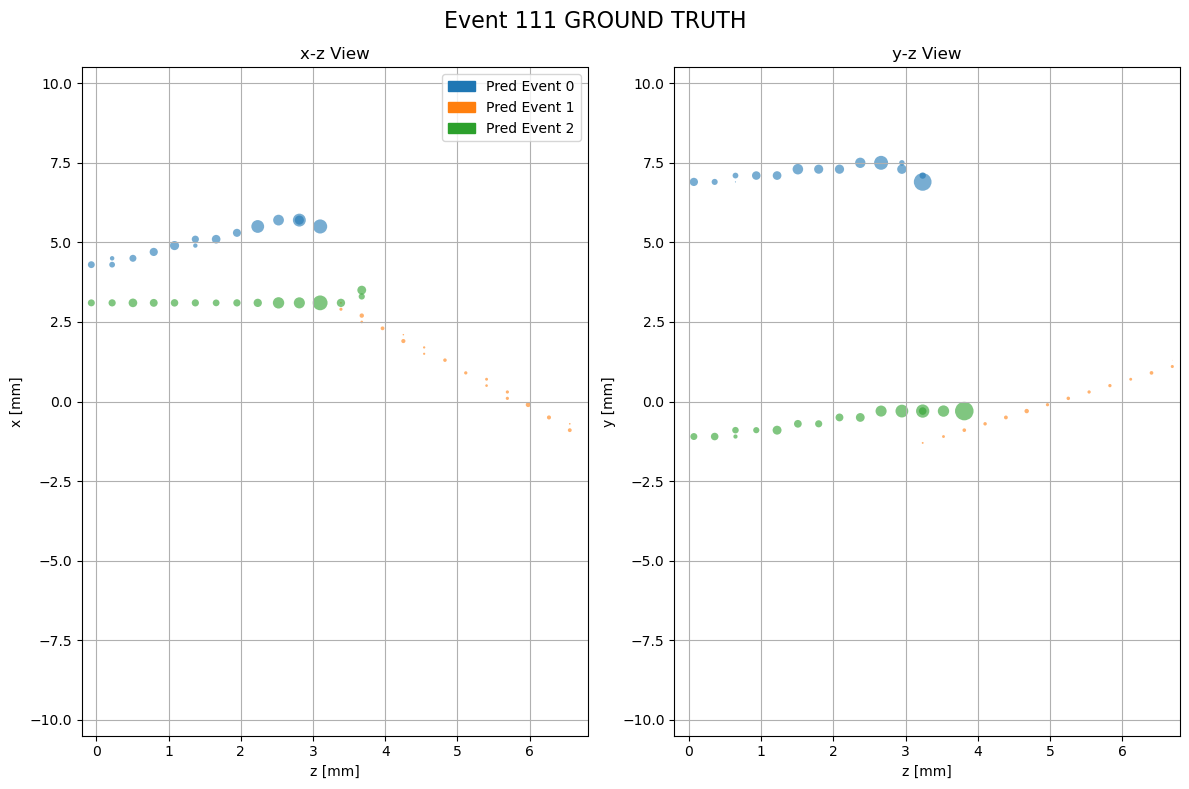

Prediction: 2 Reconstructed Events


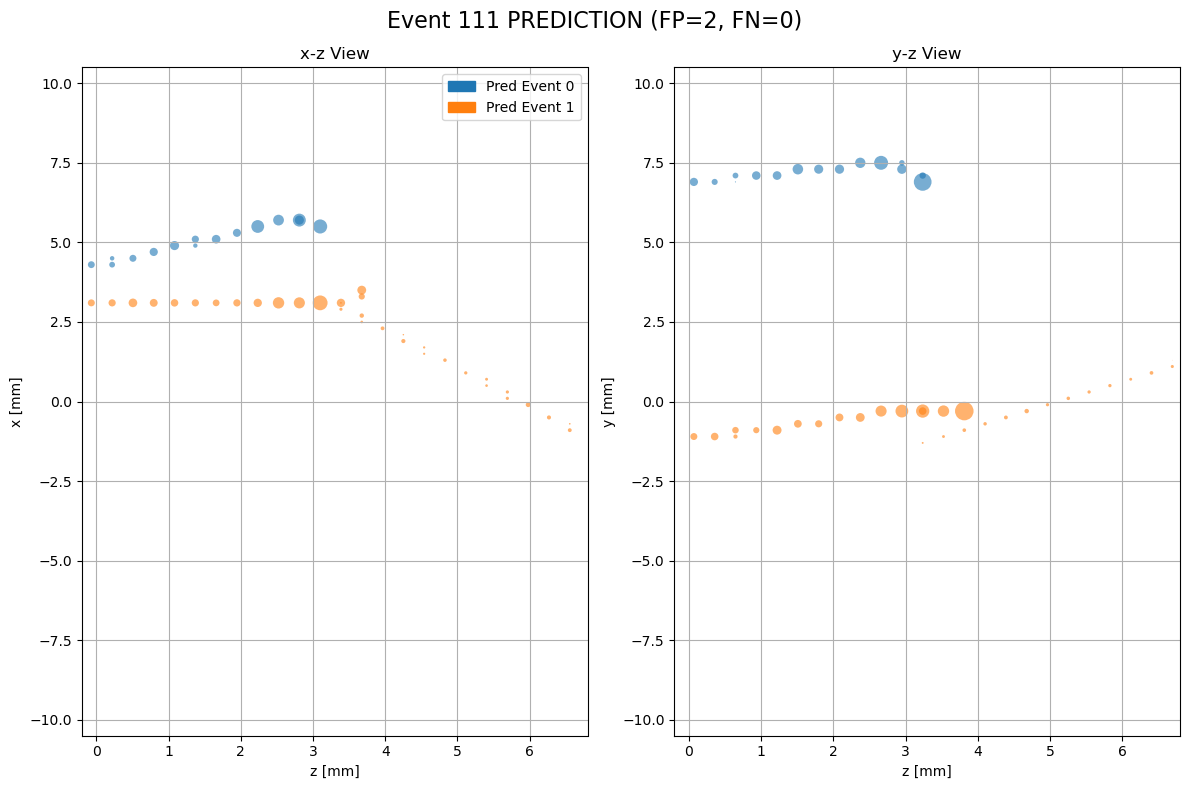

--- Event 214 Analysis (FP=2, FN=0) ---
Ground Truth: 2 Distinct Events


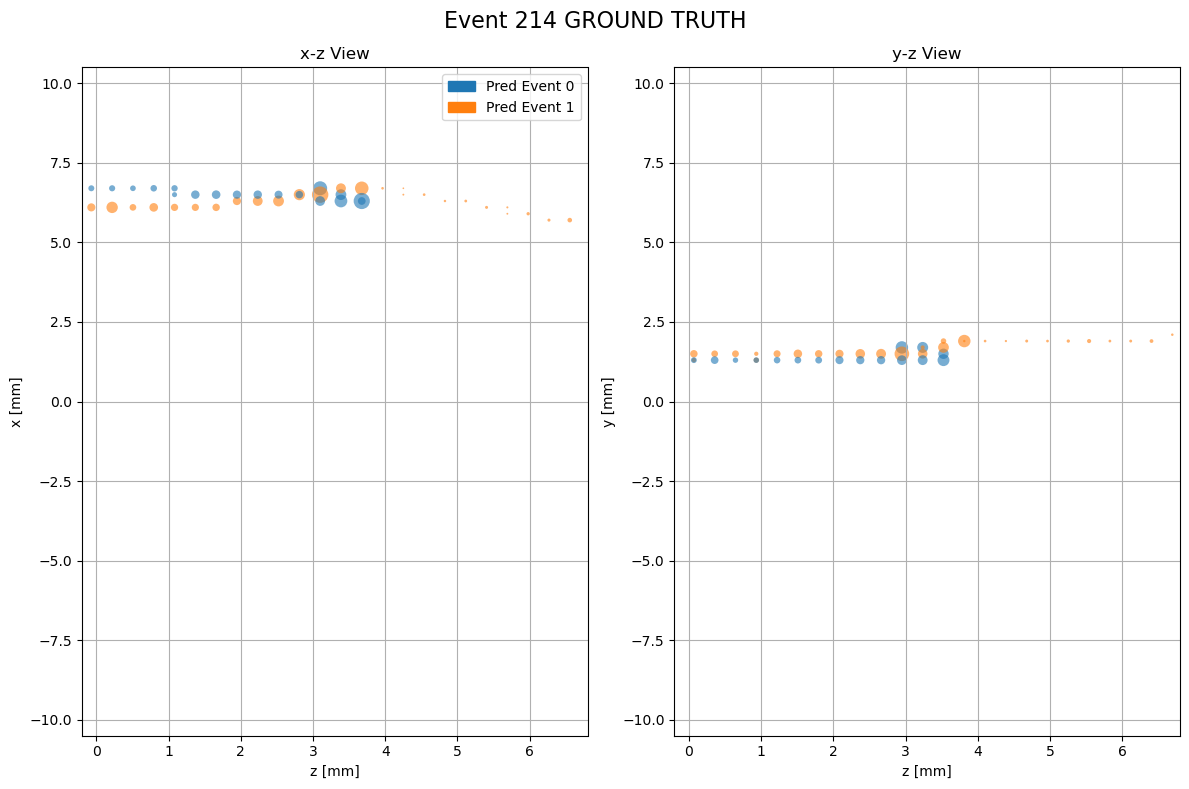

Prediction: 1 Reconstructed Events


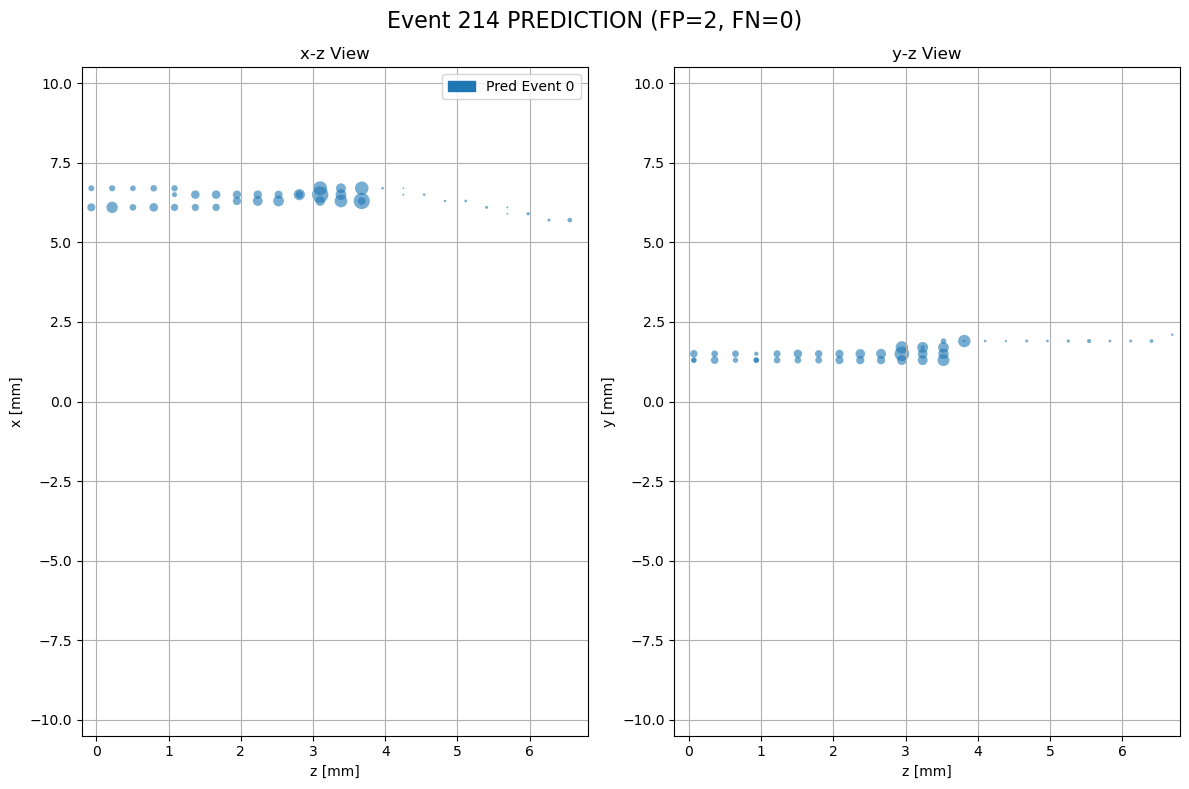

--- Event 324 Analysis (FP=4, FN=0) ---
Ground Truth: 2 Distinct Events


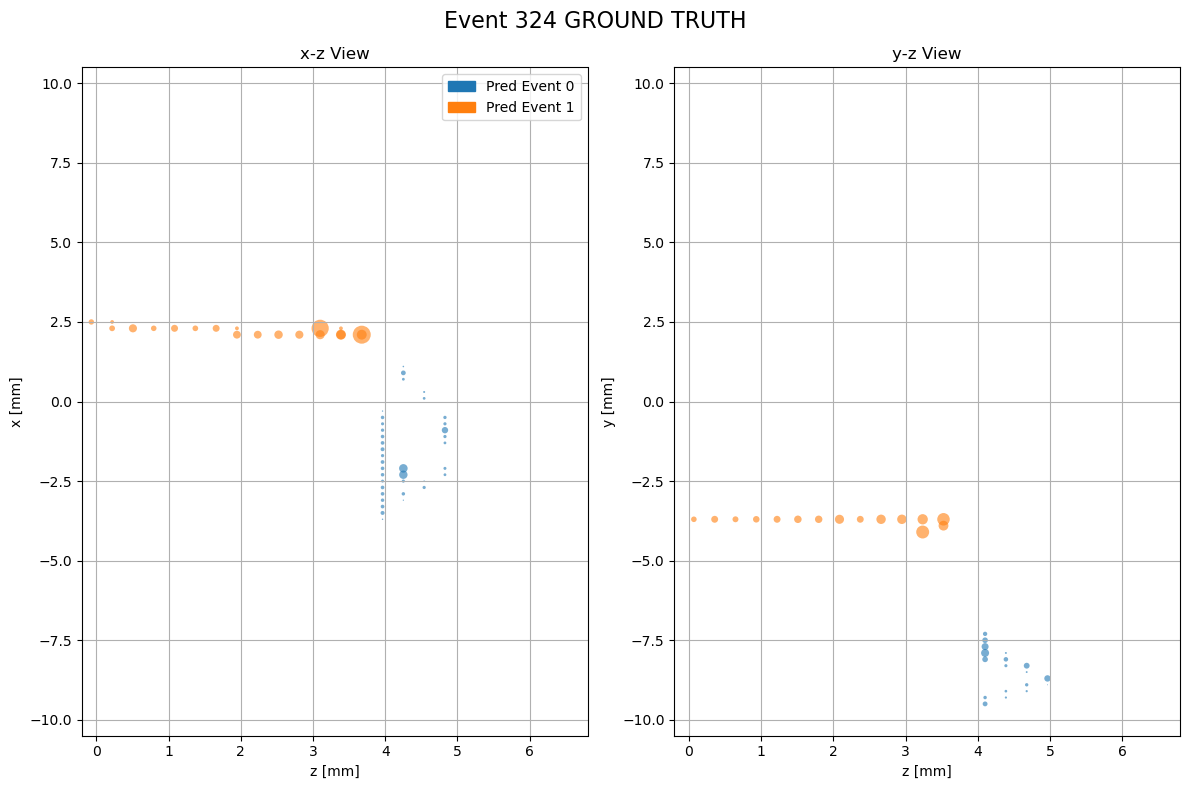

Prediction: 1 Reconstructed Events


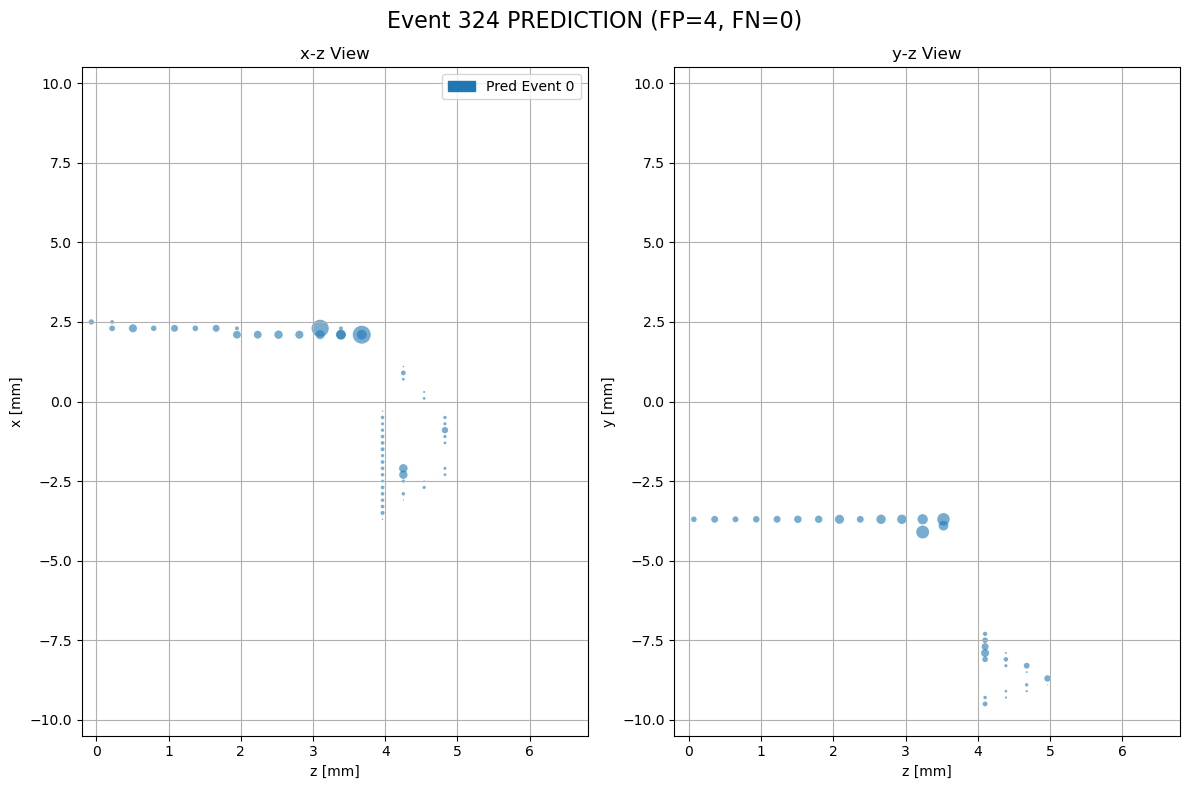

--- Event 342 Analysis (FP=2, FN=0) ---
Ground Truth: 2 Distinct Events


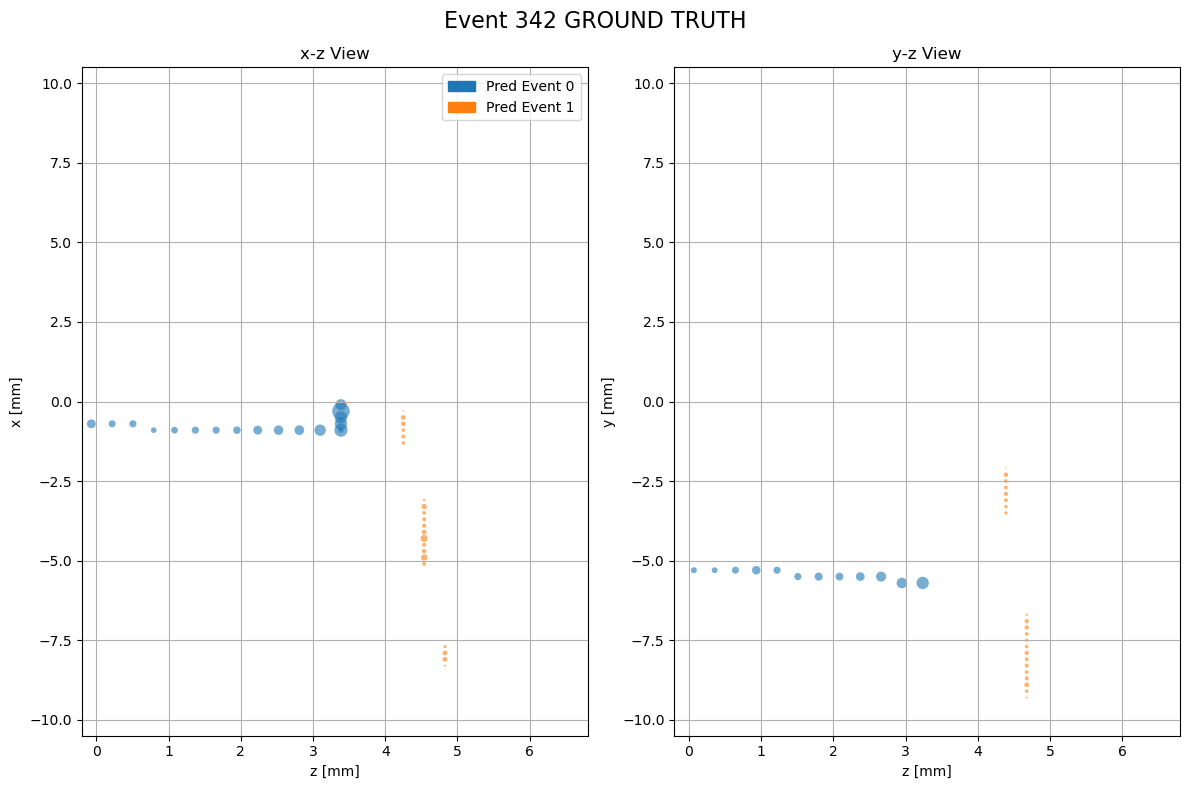

Prediction: 1 Reconstructed Events


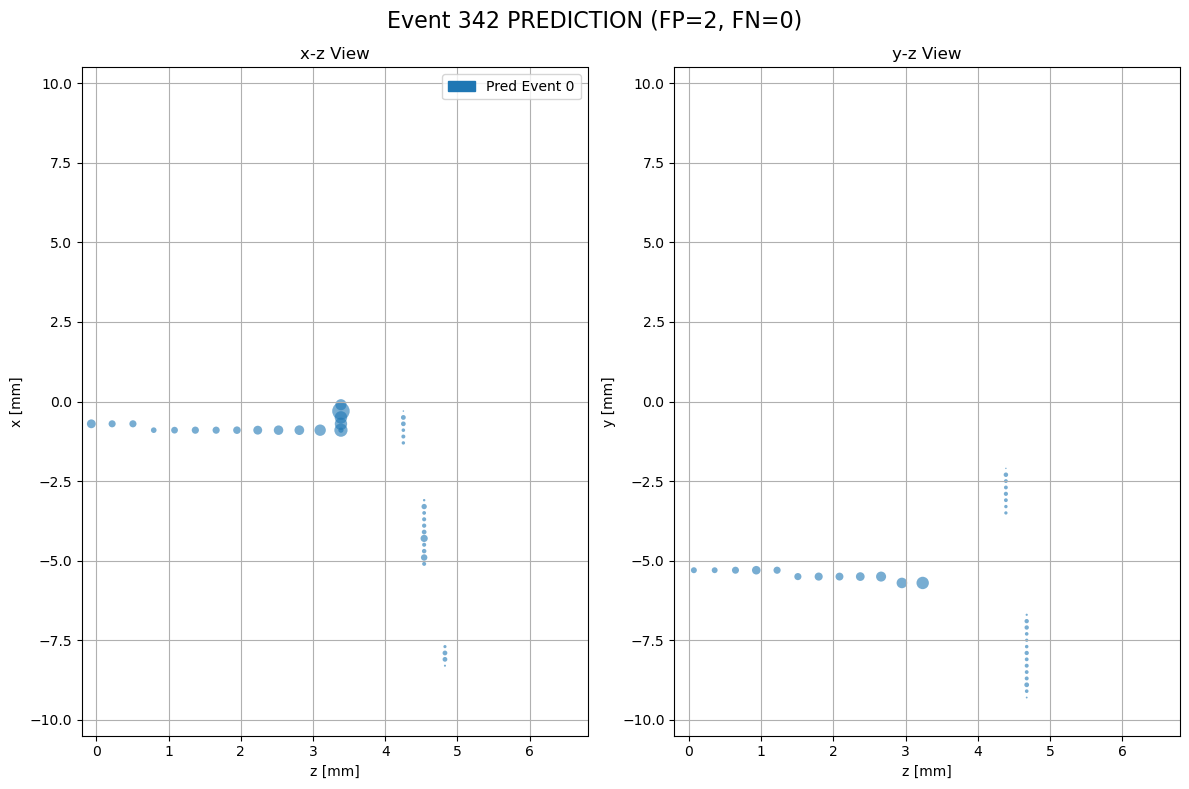

--- Event 363 Analysis (FP=2, FN=0) ---
Ground Truth: 2 Distinct Events


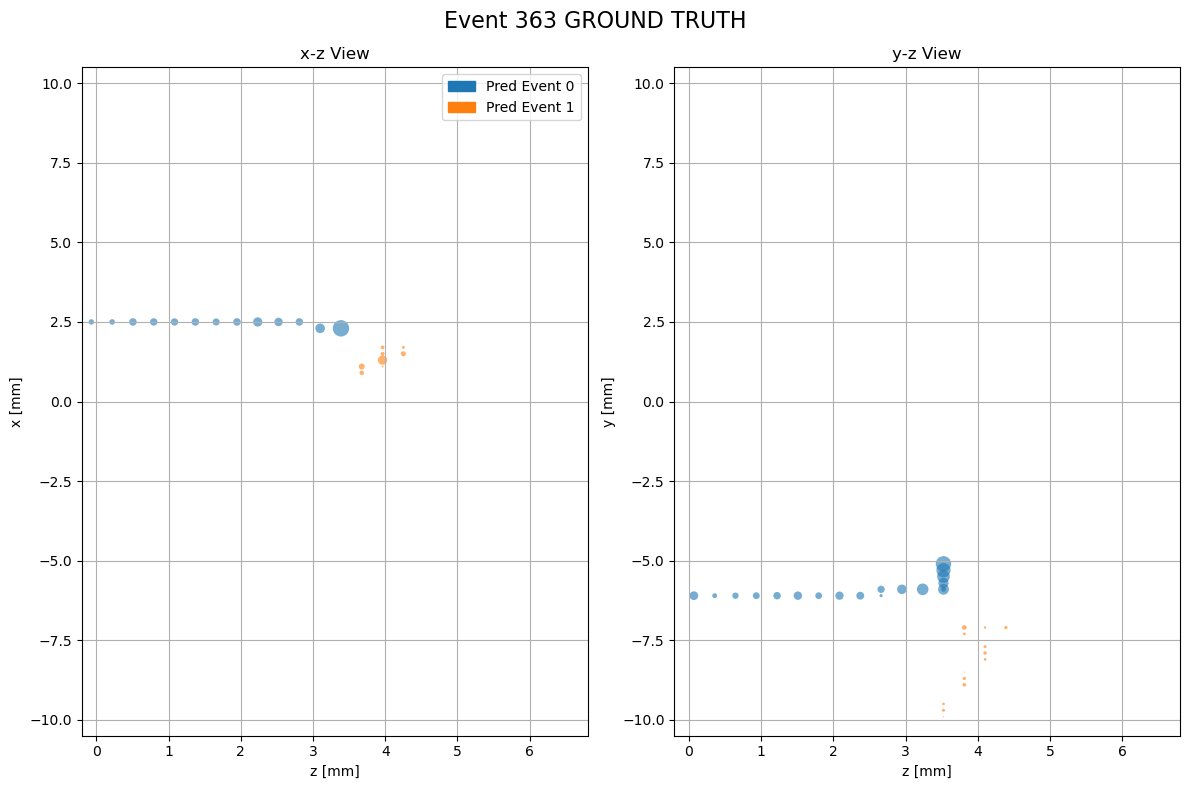

Prediction: 1 Reconstructed Events


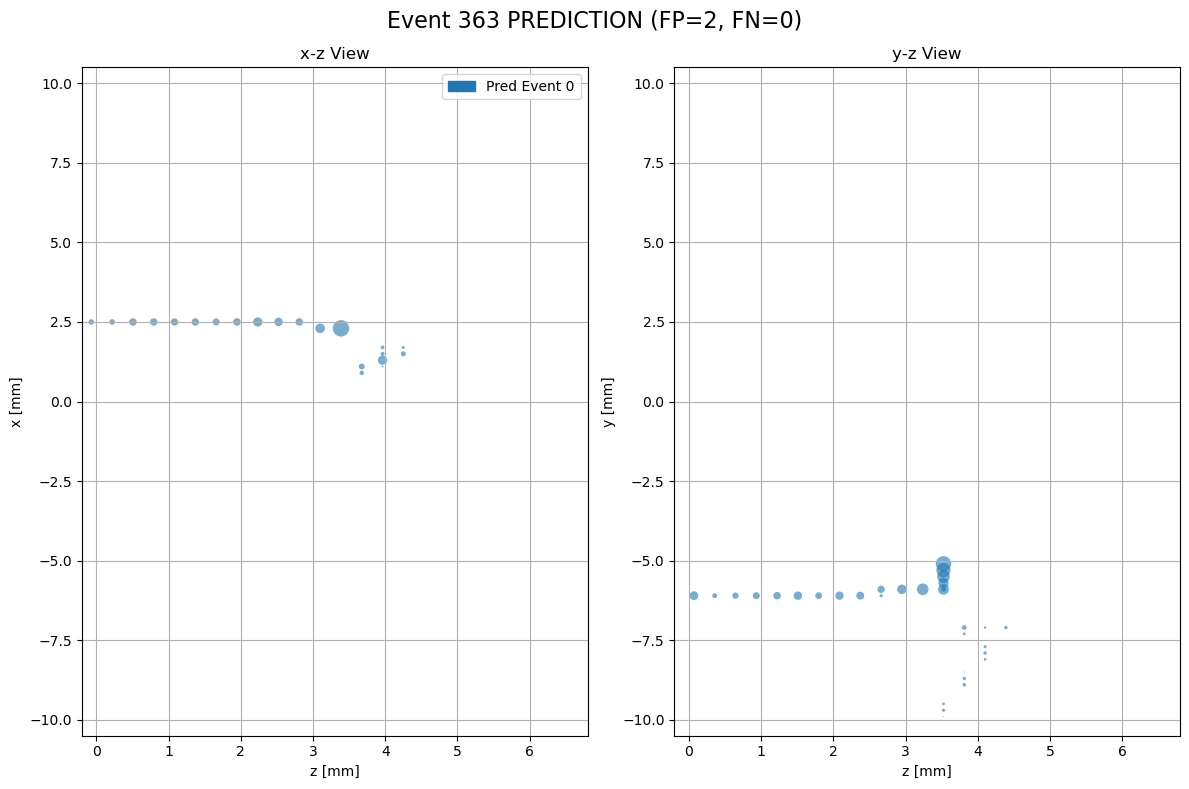

--- Event 428 Analysis (FP=2, FN=0) ---
Ground Truth: 2 Distinct Events


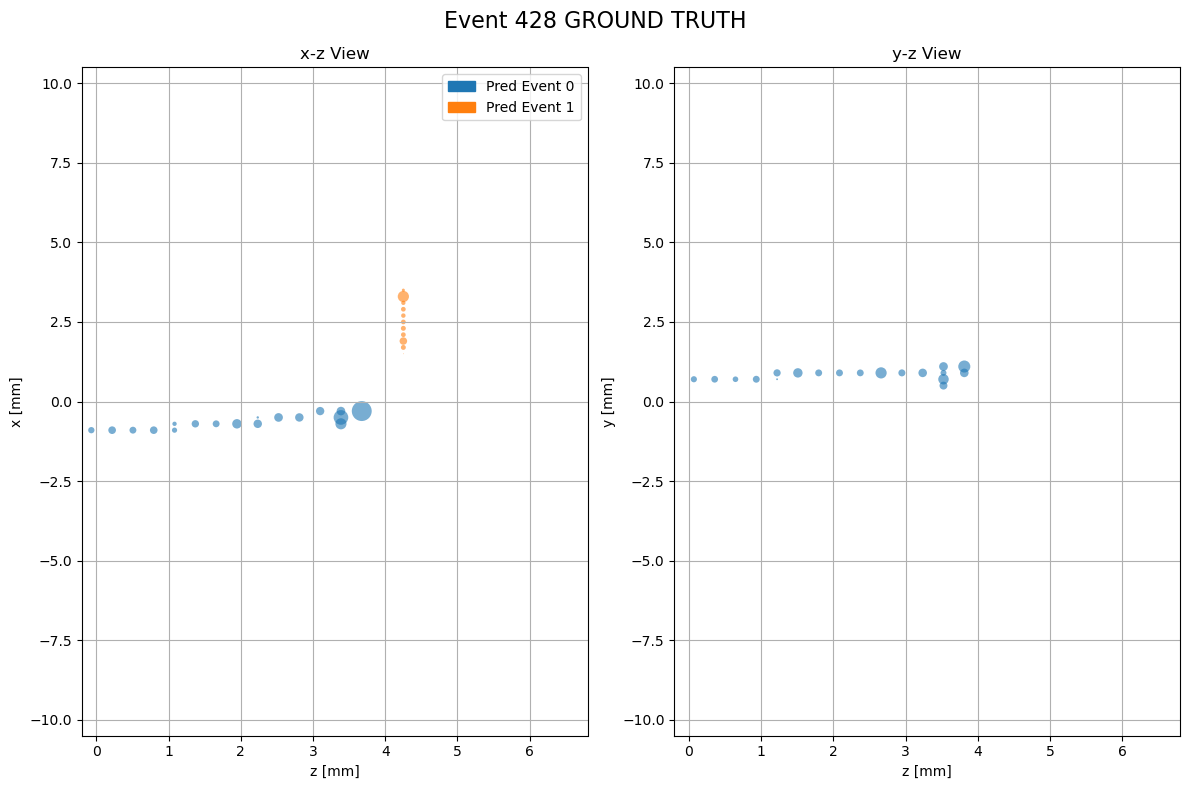

Prediction: 1 Reconstructed Events


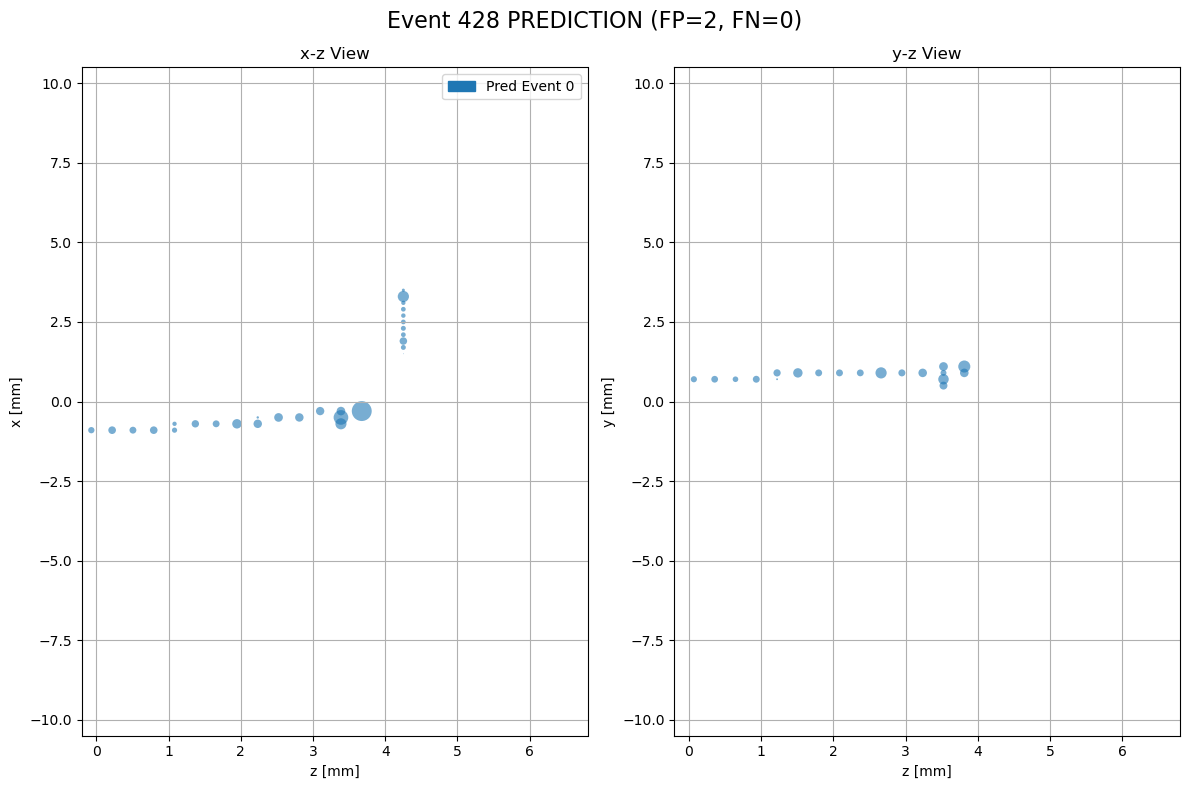

--- Event 513 Analysis (FP=4, FN=0) ---
Ground Truth: 2 Distinct Events


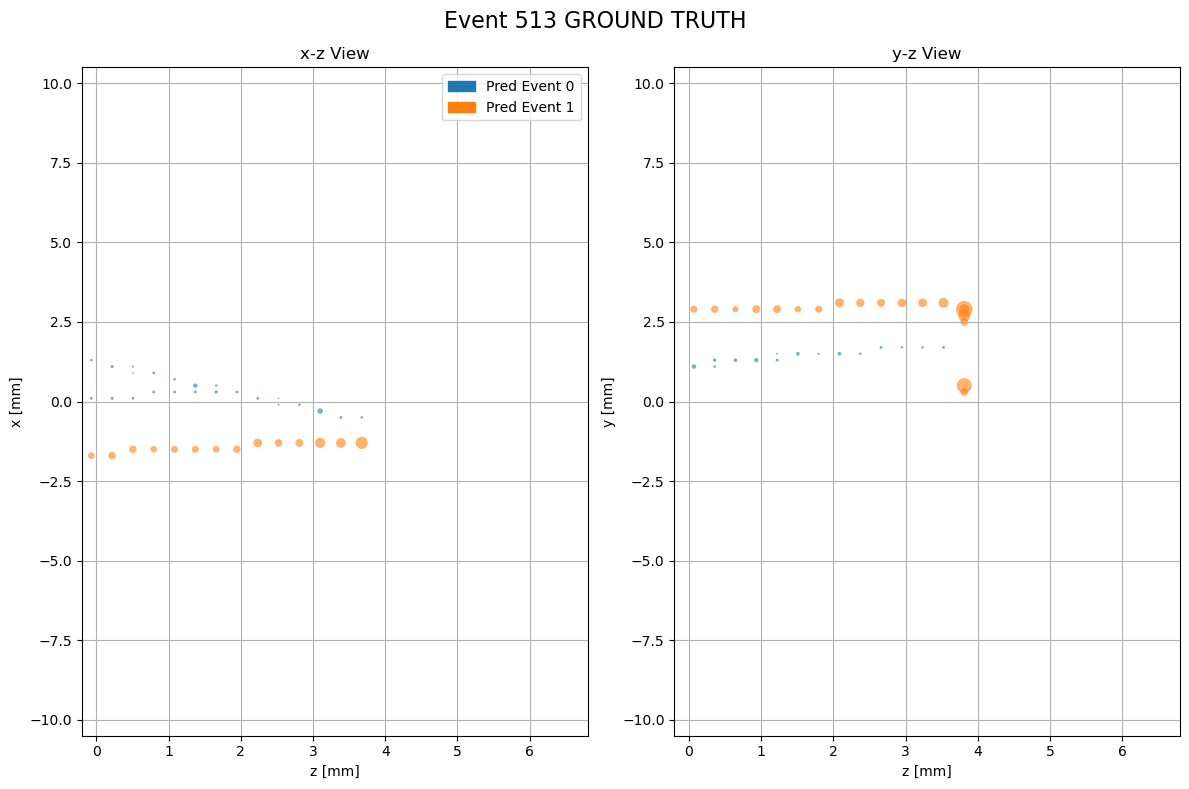

Prediction: 1 Reconstructed Events


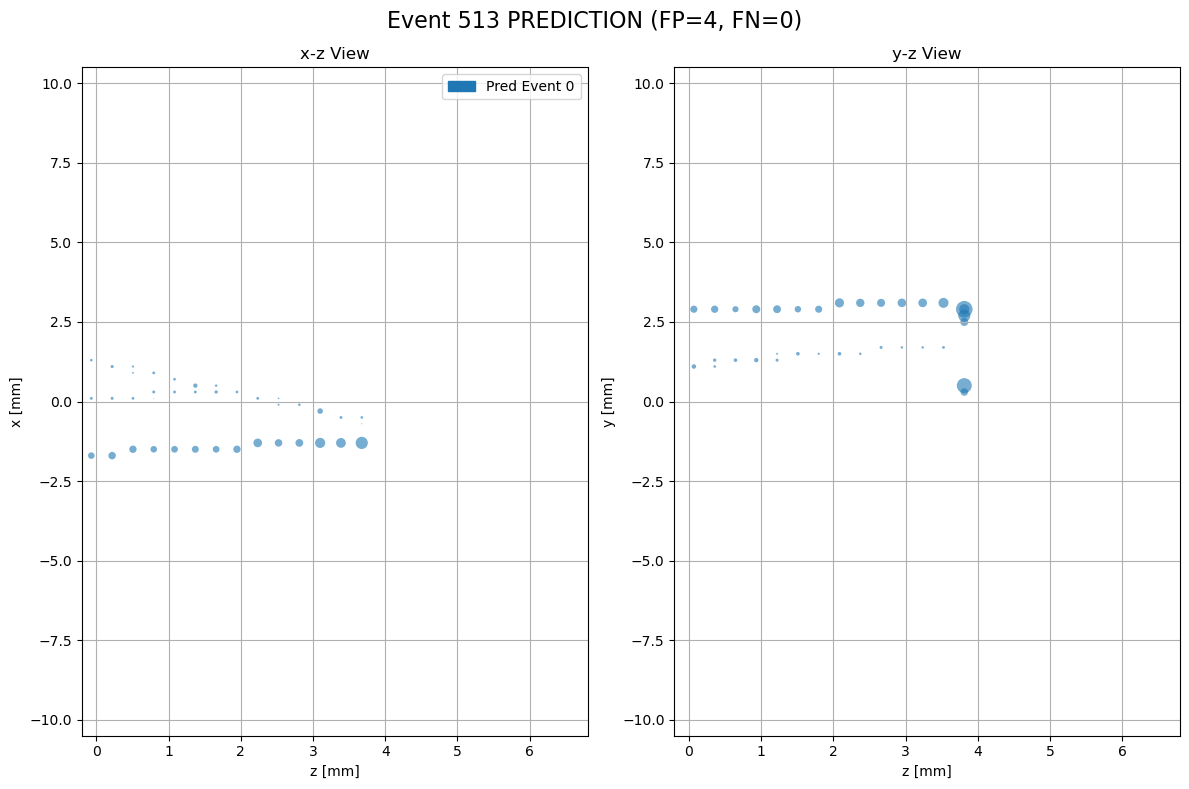

--- Event 760 Analysis (FP=0, FN=4) ---
Ground Truth: 1 Distinct Events


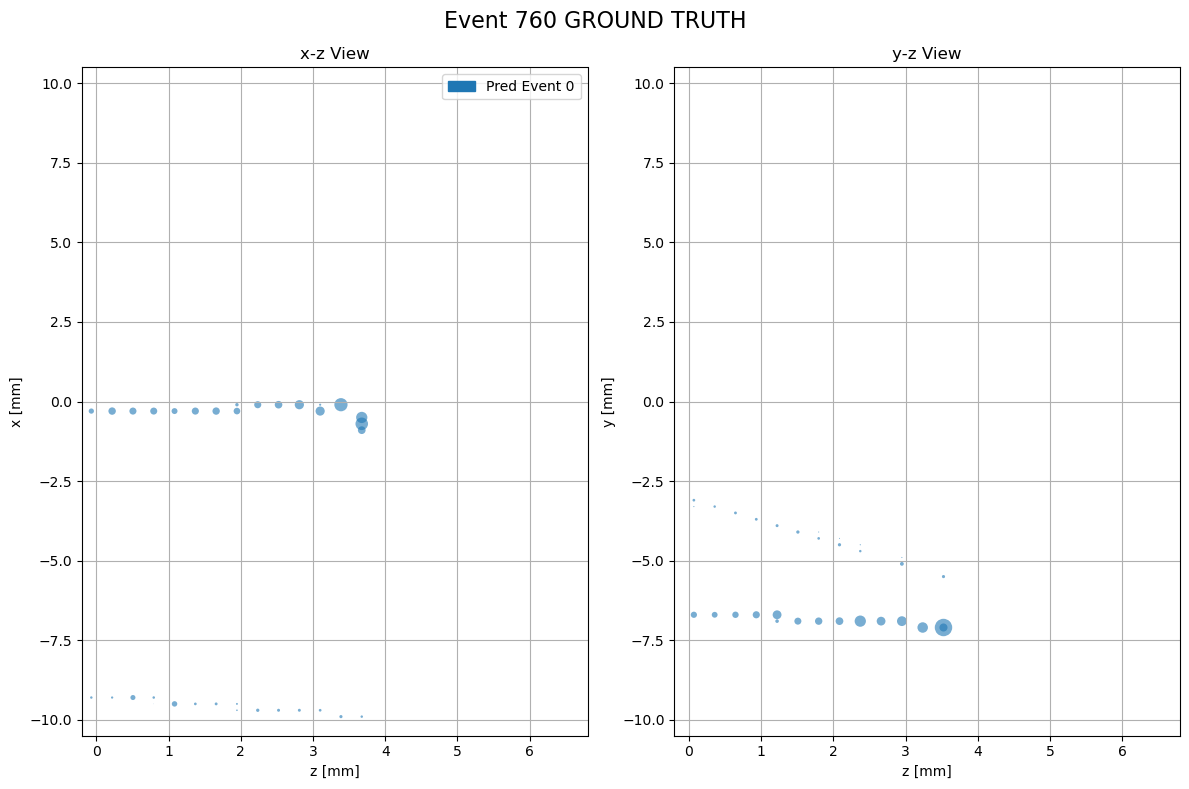

Prediction: 2 Reconstructed Events


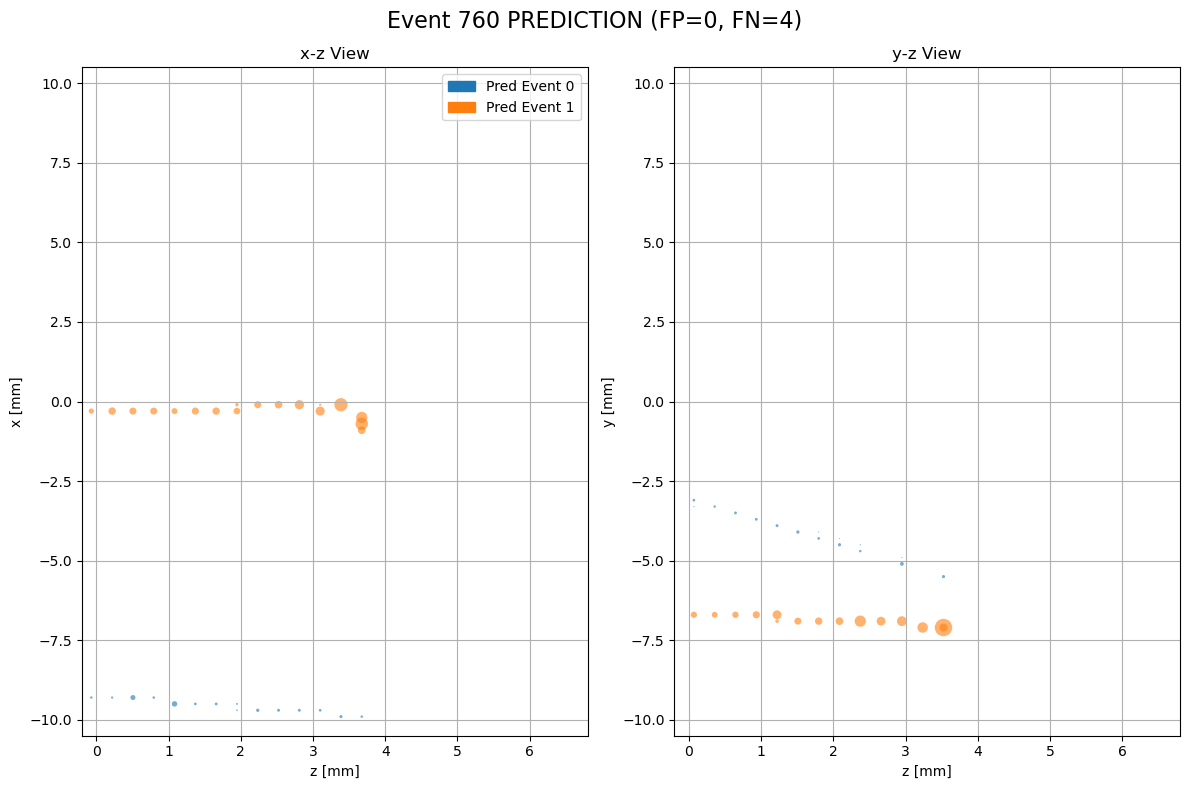

In [26]:
failures = find_builder_failures(model, val_subset, DEVICE, max_events=1000)

# 2. Visualize the worst one
for fail in failures:
    visualize_pileup_comparison(val_subset, fail)

In [9]:
#model = EventBuilder(
#    in_channels=25, hidden=128, heads=4, layers=3, dropout=0.1
#).to(DEVICE)
model.load_state_dict(torch.load('/mnt/c/Users/obbee/research/notebooks/ML/model_weights/event_builder_12_31_2025.pth'))

<All keys matched successfully>

In [ ]:
torch.save(model.state_dict(), '/mnt/c/Users/obbee/research/notebooks/ML/model_weights/event_builder_12__2025.pth')